<a href="https://www.kaggle.com/code/lalit7881/football-players-stats-2026-2027-eda?scriptVersionId=349757607" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hubertsidorowicz/football-players-stats-2026-2027/players_data-2026_2027.csv
/kaggle/input/datasets/hubertsidorowicz/football-players-stats-2026-2027/players_data_light-2026_2027.csv


## Loading dataset

In [2]:
from pathlib import Path

# Helper function to resolve data file paths dynamically
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            # Look for exact filename match
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            # Look for any file matching given suffixes
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')


In [3]:
import os

# Resolve the path for the main dataset file
data_file_1 = resolve_data_file(file_name='players_data-2026_2027.csv')
print(f"Loading data from: {data_file_1}")

# Loading the dataset into a pandas DataFrame
df = pd.read_csv(data_file_1, encoding='utf-8')

Loading data from: /kaggle/input/datasets/hubertsidorowicz/football-players-stats-2026-2027/players_data-2026_2027.csv


In [4]:
df.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,MF,Leeds United,eng Premier League,25.0,2000.0,3,2,...,0,0,0,0,5,0,0,0,2,0
1,2,Haitam Abaida,ma MAR,FW,Málaga,es La Liga,24.0,2002.0,2,0,...,0,0,0,1,2,0,6,0,0,0
2,3,James Abankwah,ie IRL,DF,Udinese,it Serie A,22.0,2004.0,3,3,...,1,0,0,5,2,0,1,1,5,0
3,4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,20.0,2006.0,4,0,...,0,0,0,2,2,0,10,0,0,0
4,5,Hamza Abdelkarim,eg EGY,FW,Barcelona,es La Liga,18.0,2008.0,1,0,...,0,0,0,0,1,0,0,0,0,0


In [5]:
df.tail()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
2029,2030,Martín Zubimendi,es ESP,MF,Arsenal,eng Premier League,27.0,1999.0,4,0,...,0,0,0,3,0,0,0,3,2,0
2030,2031,Adam Zulevic,sk SVK,FW,Genoa,it Serie A,19.0,2007.0,1,0,...,0,0,0,1,0,0,0,0,0,0
2031,2032,Martin Ødegaard,no NOR,MF,Arsenal,eng Premier League,27.0,1998.0,4,4,...,0,0,0,0,6,0,6,1,4,0
2032,2033,Leo Østigård,no NOR,DF,Genoa,it Serie A,26.0,1999.0,4,4,...,3,0,0,6,1,0,0,4,5,0
2033,2034,Luka Đurić,rs SRB,MF,Paderborn 07,de Bundesliga,23.0,2003.0,1,0,...,0,0,0,0,1,0,0,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2034 entries, 0 to 2033
Columns: 102 entries, Rk to OG
dtypes: float64(41), int64(40), object(21)
memory usage: 1.6+ MB


In [7]:
df.describe()

,Rk,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
count,2034.000000,2032.000000,2032.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,...,2034.00000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.00000,2034.000000,2034.000000,2034.000000
mean,1017.500000,25.449803,2000.313484,2.926254,2.044248,183.617011,2.039872,0.271386,0.199115,0.470501,...,0.32940,0.013274,0.002950,2.183382,2.096362,0.351524,3.22468,1.706490,1.815634,0.008358
std,587.309544,4.228859,4.235748,1.231042,1.590060,126.526575,1.406677,0.693656,0.513640,0.933270,...,0.58313,0.114475,0.054246,2.305130,2.414409,0.829741,5.25308,2.252372,2.169622,0.091061
min,1.000000,15.000000,1985.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,509.250000,22.000000,1997.000000,2.000000,0.000000,65.250000,0.700000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,1017.500000,25.000000,2001.000000,3.000000,2.000000,180.000000,2.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,2.000000,1.000000,0.000000,1.00000,1.000000,1.000000,0.000000
75%,1525.750000,28.000000,2003.000000,4.000000,3.000000,271.750000,3.000000,0.000000,0.000000,1.000000,...,1.00000,0.000000,0.000000,3.000000,3.000000,0.000000,4.00000,3.000000,3.000000,0.000000
max,2034.000000,41.000000,2010.000000,6.000000,6.000000,540.000000,6.000000,6.000000,4.000000,9.000000,...,3.00000,1.000000,1.000000,24.000000,19.000000,9.000000,47.00000,16.000000,15.000000,1.000000


In [8]:
df.isnull().sum()

Rk        0
Player    0
Nation    3
Pos       0
Squad     0
         ..
Off       0
Crs       0
Int       0
TklW      0
OG        0
Length: 102, dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Rk         int64
Player    object
Nation    object
Pos       object
Squad     object
           ...  
Off        int64
Crs        int64
Int        int64
TklW       int64
OG         int64
Length: 102, dtype: object

In [11]:
df.shape

(2034, 102)

In [12]:
df.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts',
       ...
       'CrdY_stats_misc', 'CrdR_stats_misc', '2CrdY', 'Fls', 'Fld', 'Off',
       'Crs', 'Int', 'TklW', 'OG'],
      dtype='object', length=102)

In [13]:
df.nunique()

Rk        2034
Player    2001
Nation     103
Pos          9
Squad       96
          ... 
Off         10
Crs         36
Int         17
TklW        13
OG           2
Length: 102, dtype: int64

Exploratory Data Analysis Step
                Rk          Age         Born           MP       Starts  \
count  2034.000000  2032.000000  2032.000000  2034.000000  2034.000000   
mean   1017.500000    25.449803  2000.313484     2.926254     2.044248   
std     587.309544     4.228859     4.235748     1.231042     1.590060   
min       1.000000    15.000000  1985.000000     1.000000     0.000000   
25%     509.250000    22.000000  1997.000000     2.000000     0.000000   
50%    1017.500000    25.000000  2001.000000     3.000000     2.000000   
75%    1525.750000    28.000000  2003.000000     4.000000     3.000000   
max    2034.000000    41.000000  2010.000000     6.000000     6.000000   

               Min          90s          Gls          Ast          G+A  ...  \
count  2034.000000  2034.000000  2034.000000  2034.000000  2034.000000  ...   
mean    183.617011     2.039872     0.271386     0.199115     0.470501  ...   
std     126.526575     1.406677     0.693656     0.513640     0.9

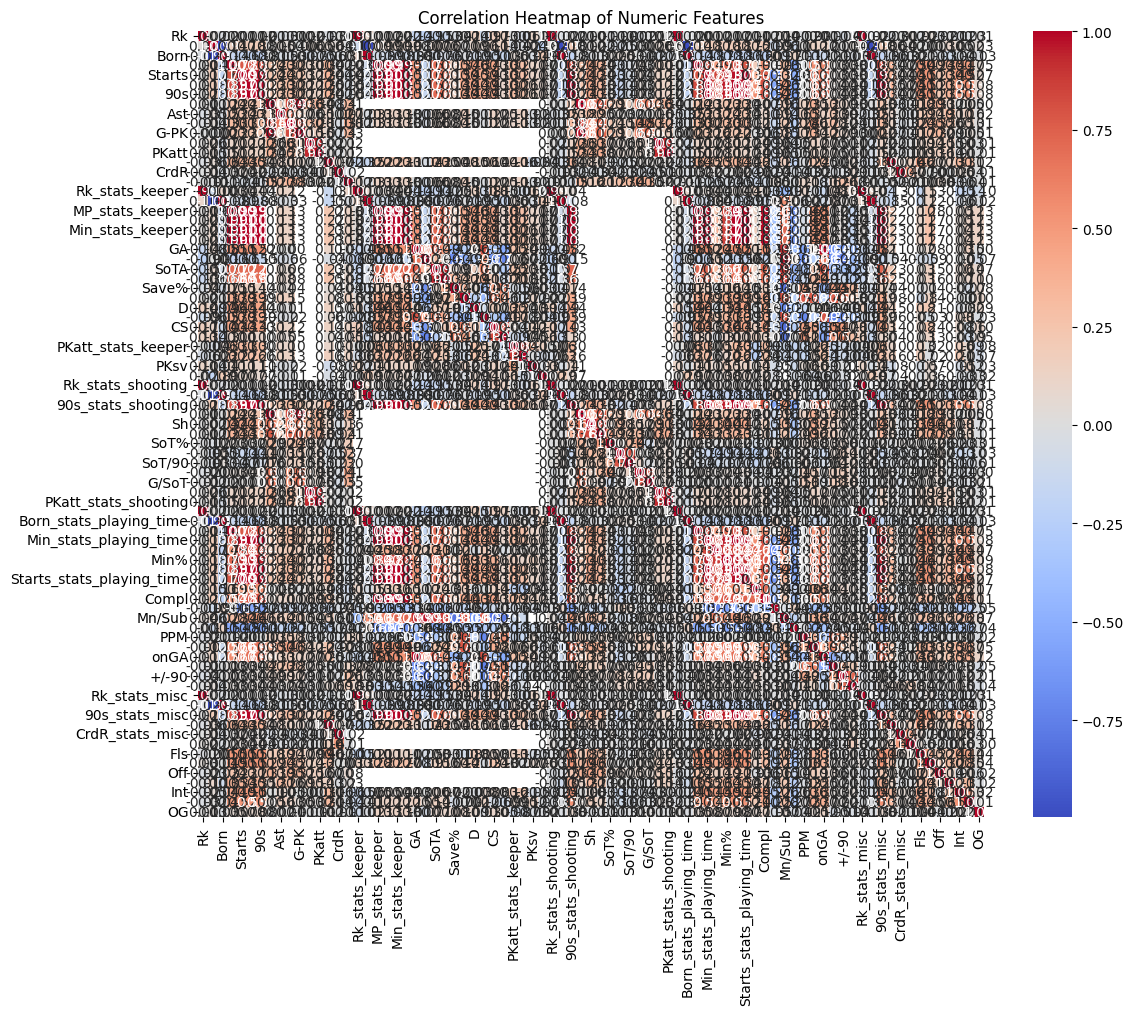

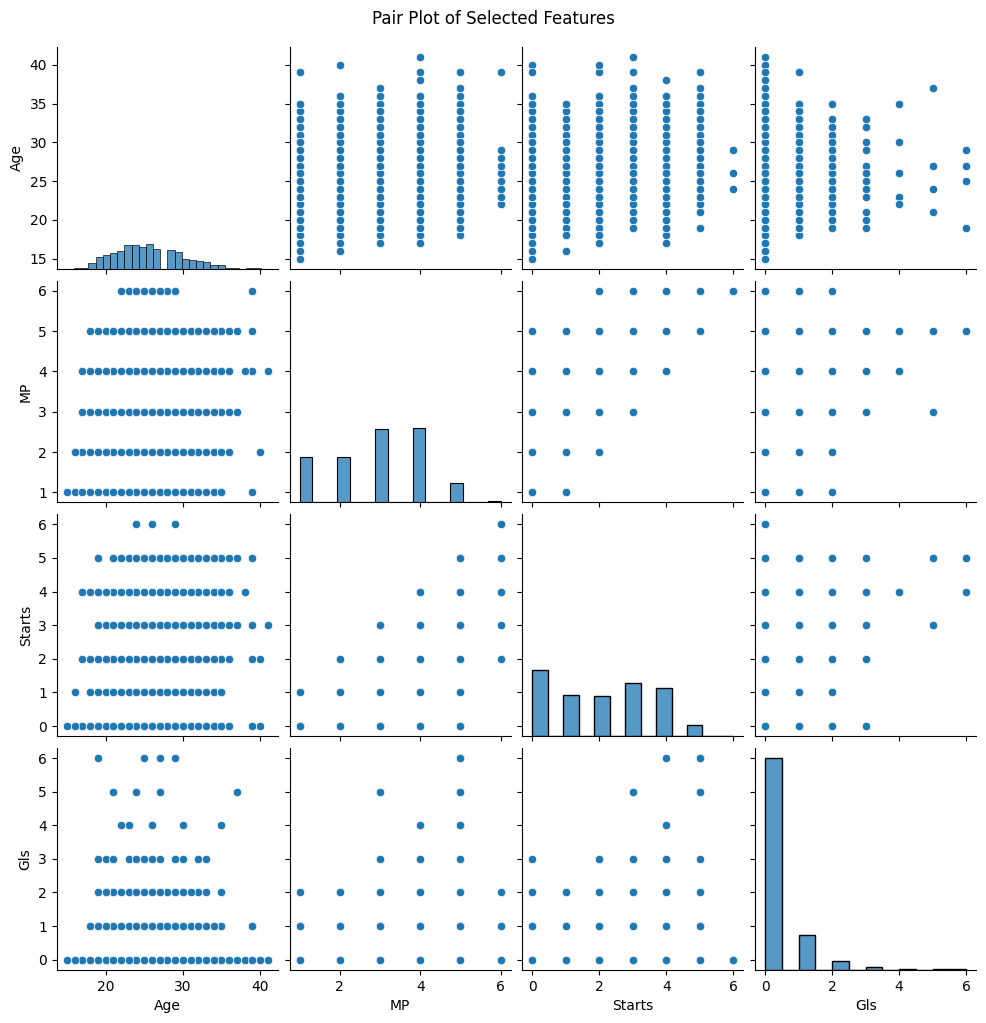

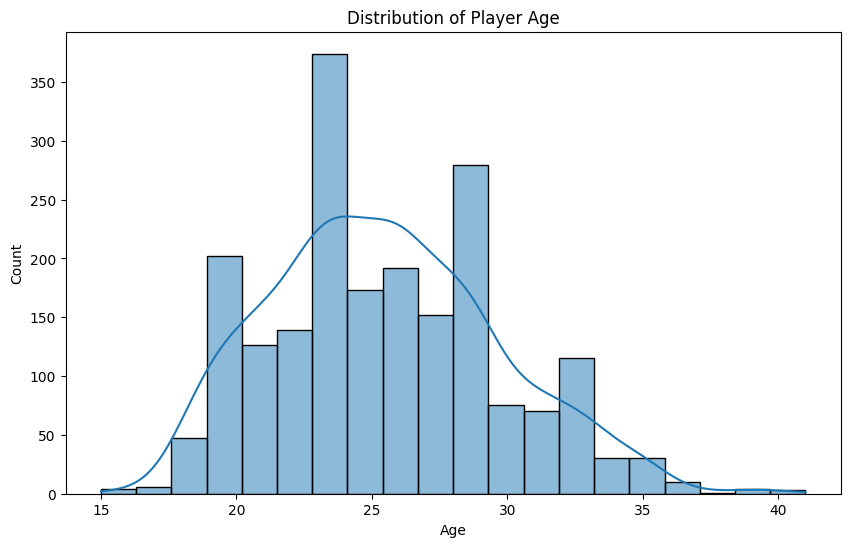

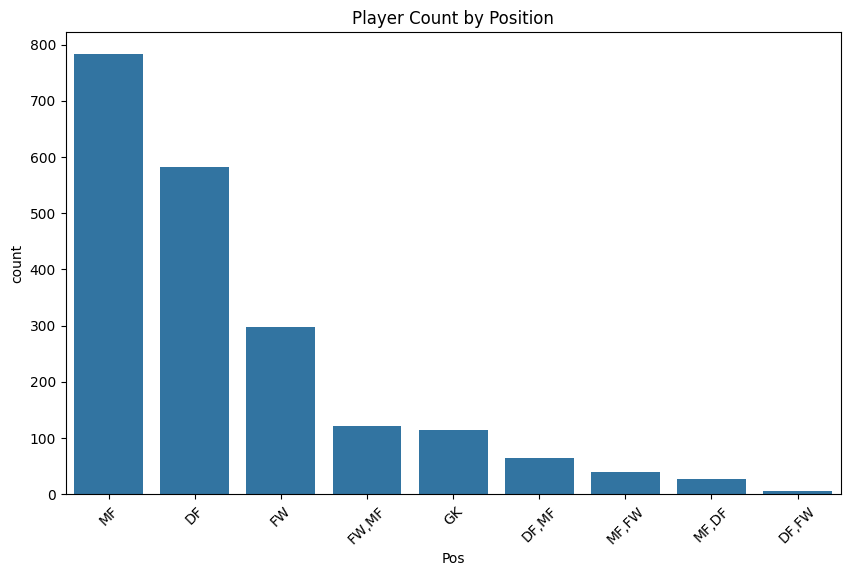

In [14]:
print('Exploratory Data Analysis Step')

# Display summary statistics for numeric columns
print(df.describe())

# Selecting numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    # Plotting a correlation heatmap for numeric features
    plt.figure(figsize=(12,10))
    corr_matrix = numeric_df.corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for a correlation heatmap.')

# Pair Plot to explore relationships among a small subset of features
selected_features = ['Age', 'MP', 'Starts', 'Gls']  # a brief selection of key performance metrics
if all(feat in df.columns for feat in selected_features):
    sns.pairplot(df[selected_features])
    plt.suptitle('Pair Plot of Selected Features', y=1.02)
    plt.show()
else:
    print('Some selected features are missing for the pair plot.')

# Histograms for distribution analysis of key metrics
plt.figure(figsize=(10,6))
sns.histplot(df['Age'], kde=True, bins=20)
plt.title('Distribution of Player Age')
plt.show()

# Bar plot for count of players by position
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Pos', order=df['Pos'].value_counts().index)
plt.title('Player Count by Position')
plt.xticks(rotation=45)
plt.show()

In [15]:
print('Data Cleaning and Preprocessing Step')

# Check for missing values
missing_summary = df.isnull().sum()
print('Missing values per column:')
print(missing_summary[missing_summary > 0])

# Dropping or imputing missing values can be necessary depending on the column. In this case, 
# we will drop rows with missing target values and use median imputation for numeric features if needed.

# For demonstration, let's fill missing numeric values with the median. In production grade code,
# one should evaluate the impact of imputation on the analysis.
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Convert 'Born' column if it is interpreted as a year, it can be kept as numeric.
# Note: there are no explicit date-columns provided; however, if any column contained dates,
# appropriate parsing with pd.to_datetime() would be used.

print('Data cleaning completed.')

Data Cleaning and Preprocessing Step
Missing values per column:
Nation                          3
Age                             2
Born                            2
Rk_stats_keeper              1919
Nation_stats_keeper          1919
Pos_stats_keeper             1919
Comp_stats_keeper            1919
Age_stats_keeper             1919
Born_stats_keeper            1919
MP_stats_keeper              1919
Starts_stats_keeper          1919
Min_stats_keeper             1919
90s_stats_keeper             1919
GA                           1919
GA90                         1919
SoTA                         1919
Saves                        1919
Save%                        1920
W                            1920
D                            1920
L                            1920
CS                           1919
CS%                          1920
PKatt_stats_keeper           1919
PKA                          1919
PKsv                         1919
PKm                          1919
Nation_stats_shoot

Predictive Modeling Step
R^2 Score of the model: 0.061


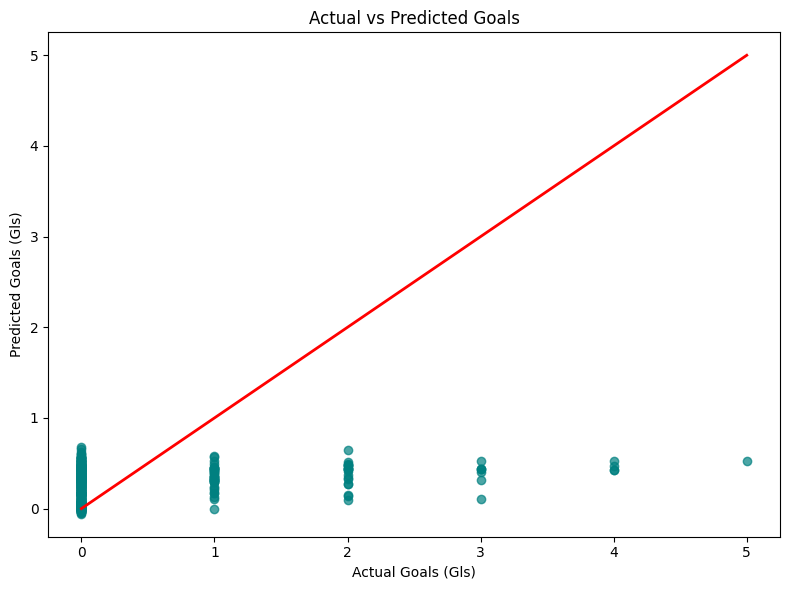

In [16]:
print('Predictive Modeling Step')

# In this section, we attempt to predict the number of goals (Gls) scored by players
# using a selection of features. A linear regression model is used for its interpretability.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Selecting a subset of features that are hypothesized to have predictive power for 'Gls'
features = ['Age', 'MP', 'Starts', '90s']
target = 'Gls'

# Verify if all features are present
if all(col in df.columns for col in features + [target]):
    X = df[features]
    y = df[target]

    # Splitting data into training and testing sets (80/20 split)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Creating and training the linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predictions on the testing set
    y_pred = model.predict(X_test)

    # Calculating prediction accuracy using the R^2 score
    accuracy = r2_score(y_test, y_pred)
    print(f"R^2 Score of the model: {accuracy:.3f}")

    # Optional: Visualizing actual vs predicted values
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
    plt.xlabel('Actual Goals (Gls)')
    plt.ylabel('Predicted Goals (Gls)')
    plt.title('Actual vs Predicted Goals')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
    plt.tight_layout()
    plt.show()
else:
    print('Missing one or more required features for modeling.')

## Thank you..pls upvote!!!!!!!!!!
